# California Housing — Exploratory Analysis & Baseline Regression

A compact, reproducible analysis of the **California Housing** dataset, combining exploratory data analysis, statistical inference, geographic comparisons, and an interpretable Ordinary Least Squares (OLS) baseline.

The notebook moves from **data understanding → statistical exploration → regional analysis → baseline modeling → diagnostics → feature ablation → final test evaluation**.

> **Scope:** This is an educational machine-learning project and a modeling benchmark, not financial or investment advice.

### What is covered

1. Dataset structure, distributions, and outliers
2. Correlation and feature–target relationships
3. A 95% confidence interval for median income
4. Geographic comparisons: North vs South and Coastal vs Inland
5. Train / validation / test methodology
6. Baseline OLS regression and statistical inference
7. Residual diagnostics and heteroscedasticity testing
8. Feature ablation using validation RMSE / MAE
9. Final test-set evaluation
10. Practical conclusions and next modeling steps

## 1. Dataset and analytical context

The California Housing dataset contains 20,640 observations and eight predictor variables describing income, household structure, population, age, and geographic location. The target, `MedHouseVal`, represents median house value in units of **$100,000s**.

The goal is not to build the strongest possible predictive model. Instead, the goal is to establish a **transparent baseline** and understand which signals, assumptions, and geographic patterns are present before moving to more complex models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm #import the relevant tools

from sklearn.datasets import fetch_california_housing #data
from sklearn.model_selection import train_test_split #splits for train/test 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #modelling metrics 

sns.set_theme(style="whitegrid")

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 20,640
Columns: 9


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Data quality and descriptive statistics

Before modeling, we inspect data types, completeness, scale, and distribution. This determines whether missing-value treatment or obvious transformations are required and helps surface unusually dispersed variables.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
summary = df.describe().T #transposed to have the features as the observations rather then the columns
summary

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Key observations

- The dataset contains **20,640 complete rows** with no missing values.
- Several variables have substantial dispersion and outliers, especially `AveRooms`, `Population`, and `AveOccup`.
- The target has a median of roughly **1.80**, equivalent to about **$180,000** in the dataset's target units, with a maximum close to **$500,000**.

These distributions make it important to inspect relationships visually rather than relying only on summary statistics.

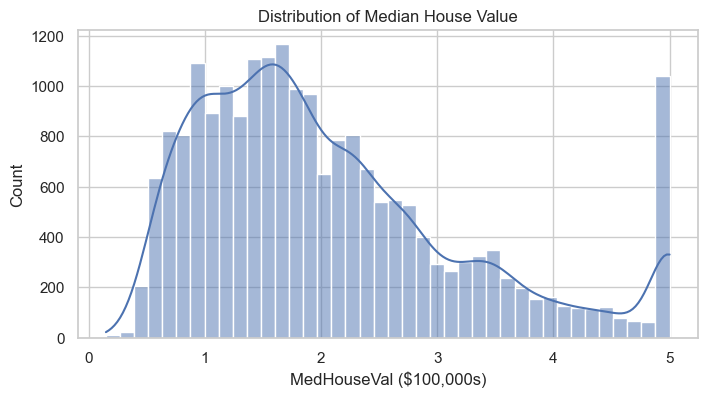

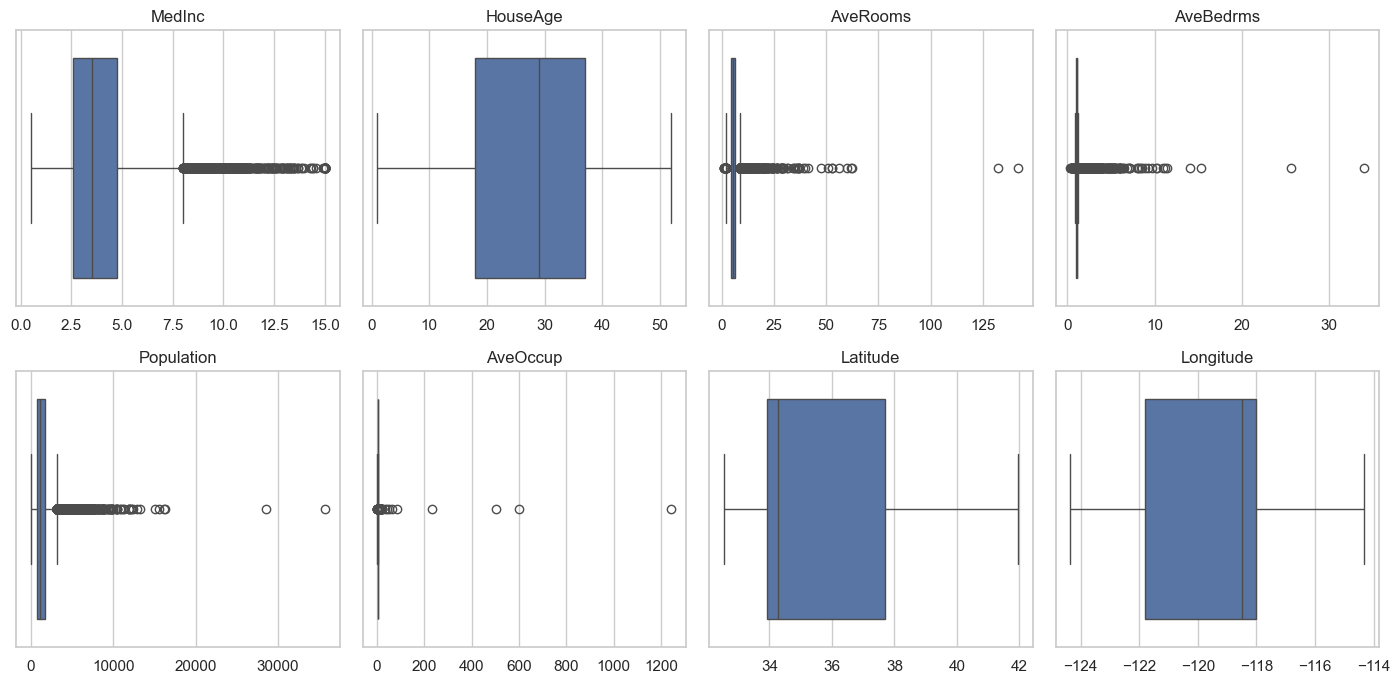

In [5]:
# Target distribution
plt.figure(figsize=(8, 4))
sns.histplot(df["MedHouseVal"], bins=40, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("MedHouseVal ($100,000s)")
plt.ylabel("Count")
plt.show()

# Feature boxplots
feature_cols = housing.feature_names
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, col in zip(axes.ravel(), feature_cols): # zip pairs each axis with its corresponding feature
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 3. Correlation and feature relationships

Correlation is used here as an **exploratory screening tool**, not as proof of causation. It helps identify which variables have the strongest linear association with the target and highlights potential collinearity between predictors.

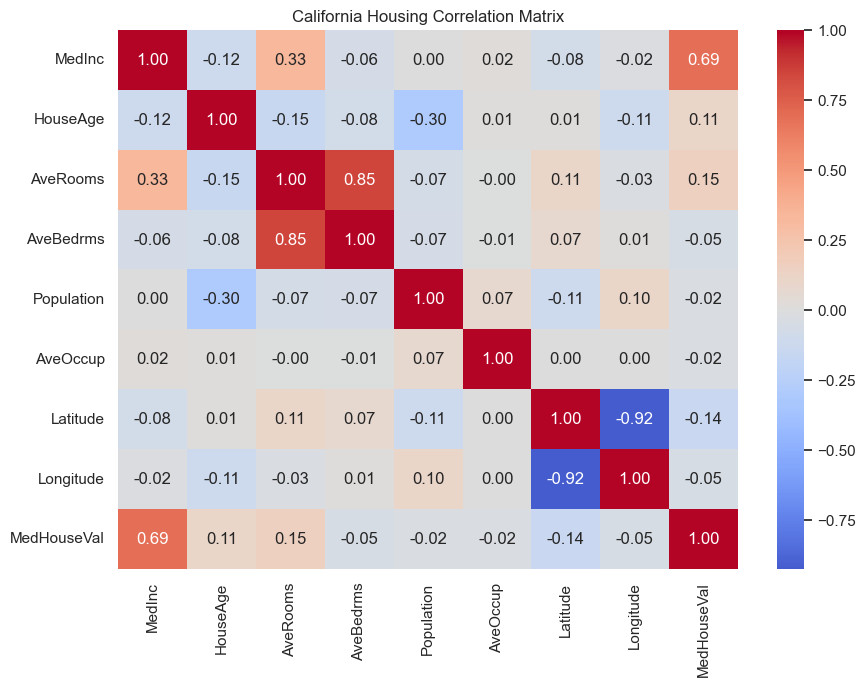

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: correlation_with_target, dtype: float64

In [6]:
correlations = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("California Housing Correlation Matrix")
plt.show()

target_correlations = (
    correlations["MedHouseVal"]
    .sort_values(ascending=False)
    .rename("correlation_with_target")
)
target_correlations

### Feature–target patterns

`MedInc` stands out as the strongest linear correlate of `MedHouseVal` (about **0.69**). `AveRooms` and `HouseAge` show weaker positive associations, while `Latitude` is moderately negative. `AveRooms` and `AveBedrms` are themselves strongly correlated, which is a useful warning when interpreting individual OLS coefficients.

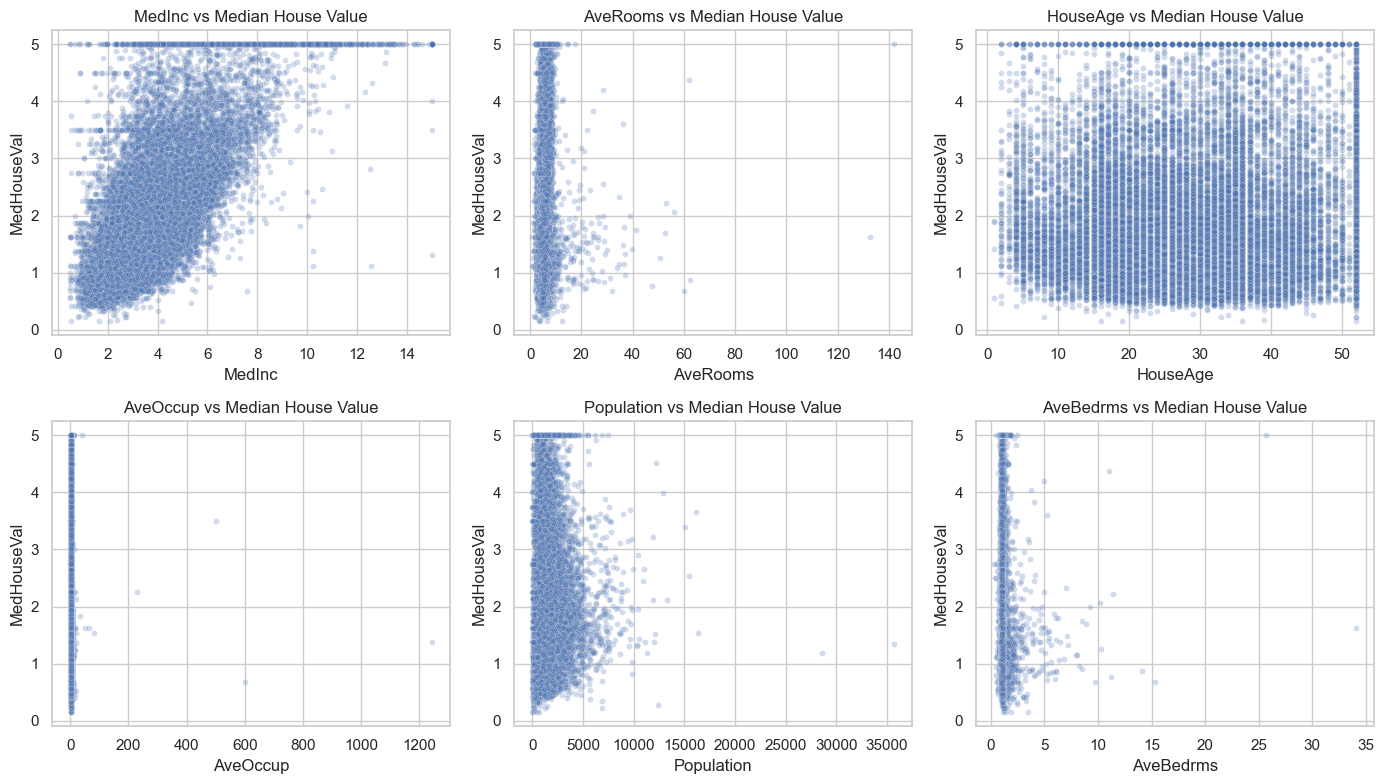

In [8]:
plot_features = ["MedInc", "AveRooms", "HouseAge", "AveOccup", "Population", "AveBedrms"] #selects the features to visualize

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), plot_features): #zip pairs each axis with its corresponding feature
    sns.scatterplot(data=df, x=col, y="MedHouseVal", alpha=0.25, s=18, ax=ax)
    ax.set_title(f"{col} vs Median House Value")
plt.tight_layout() # adjusts spacing to prevent overlapping elements
plt.show()

## 4. Statistical inference: 95% confidence interval for Median Income

A confidence interval provides an estimate of the uncertainty around a sample mean. We use `MedInc` as a representative socioeconomic variable and calculate a 95% t-based confidence interval.

In [7]:
feature = "MedInc"
x = df[feature]

mean = x.mean()
ci_low, ci_high = st.t.interval(
    confidence=0.95,
    df=len(x) - 1,
    loc=mean,
    scale=st.sem(x),
) # confidence interval implementation follows the referenced educational material

print(f"{feature} mean: {mean:.3f}")
print(f"95% CI: ({ci_low:.3f}, {ci_high:.3f})")

MedInc mean: 3.871
95% CI: (3.845, 3.897)


## 5. Geographic analysis

The dataset includes latitude and longitude, allowing a simple geographic segmentation. These boundaries are **analytical heuristics**, not official definitions of California regions:

- **North vs South:** latitude split at 37.0°
- **Coastal vs Inland:** longitude split at −120.0°

We compare house-value distributions and then test whether the group means differ statistically.

In [9]:
border_lat = 37.0
north = df[df["Latitude"] >= border_lat]
south = df[df["Latitude"] < border_lat]

border_lon = -120.0
coastal = df[df["Longitude"] <= border_lon]
inland = df[df["Longitude"] > border_lon]

print(f"North: {len(north):,} | South: {len(south):,}")
print(f"Coastal: {len(coastal):,} | Inland: {len(inland):,}")

north_south_t = st.ttest_ind(
    north["MedHouseVal"], south["MedHouseVal"], equal_var=False
)
coastal_inland_t = st.ttest_ind(
    coastal["MedHouseVal"], inland["MedHouseVal"], equal_var=False
)

print(f"North vs South: t={north_south_t.statistic:.3f}, p={north_south_t.pvalue:.5f}")
print(f"Coastal vs Inland: t={coastal_inland_t.statistic:.3f}, p={coastal_inland_t.pvalue:.5f}")

North: 7,573 | South: 13,067
Coastal: 8,207 | Inland: 12,433
North vs South: t=-1.784, p=0.07452
Coastal vs Inland: t=-1.297, p=0.19470


### Interpretation

In the original analysis, neither regional comparison reached the conventional 5% significance threshold:

- **North vs South:** p ≈ **0.075**
- **Coastal vs Inland:** p ≈ **0.195**

The distributions are still useful descriptively, but these simple splits do **not** provide strong evidence of a mean house-value difference on their own. More granular geography or richer controls would be needed for stronger conclusions.

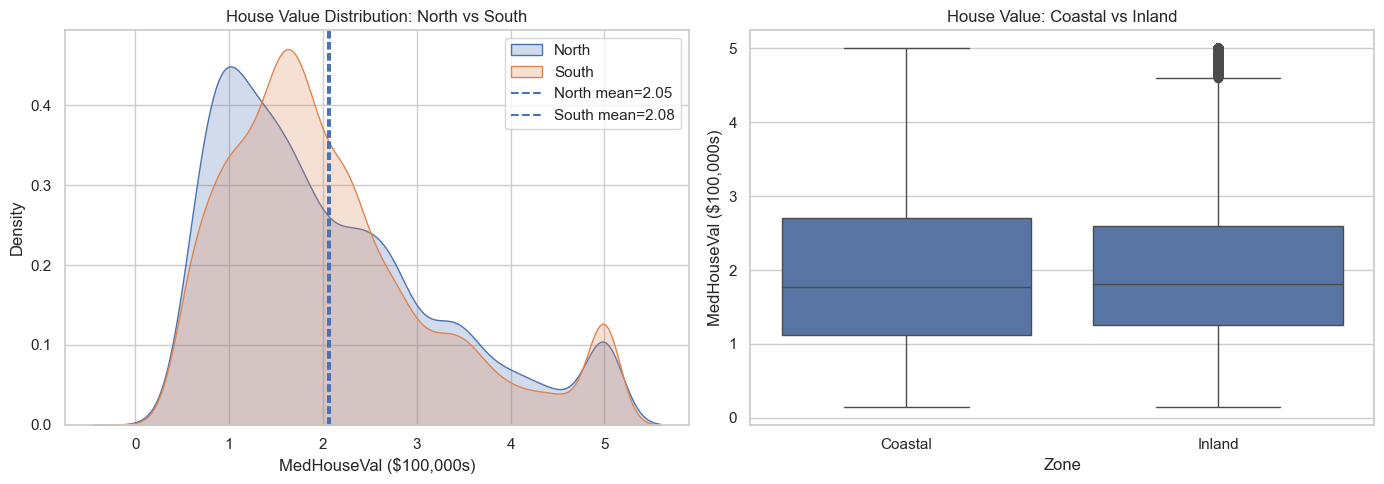

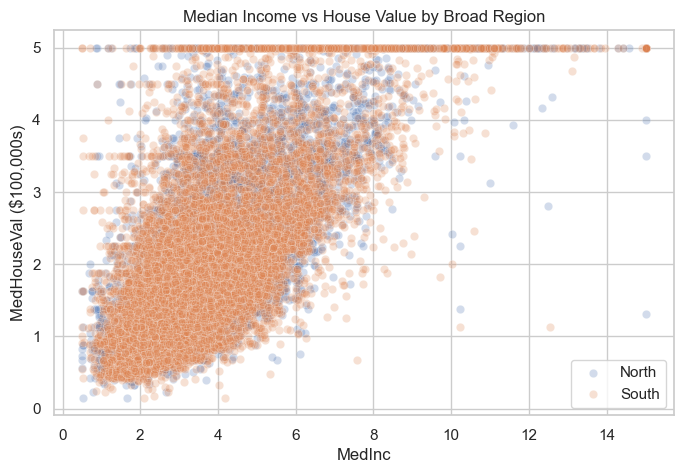

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(north["MedHouseVal"], label="North", fill=True, ax=axes[0])
sns.kdeplot(south["MedHouseVal"], label="South", fill=True, ax=axes[0])
axes[0].axvline(north["MedHouseVal"].mean(), linestyle="--", label=f"North mean={north['MedHouseVal'].mean():.2f}")
axes[0].axvline(south["MedHouseVal"].mean(), linestyle="--", label=f"South mean={south['MedHouseVal'].mean():.2f}")
axes[0].set_title("House Value Distribution: North vs South")
axes[0].set_xlabel("MedHouseVal ($100,000s)")
axes[0].legend()

sns.boxplot(
    x=["Coastal"] * len(coastal) + ["Inland"] * len(inland),
    y=pd.concat([coastal["MedHouseVal"], inland["MedHouseVal"]]),
    ax=axes[1],
)
axes[1].set_title("House Value: Coastal vs Inland")
axes[1].set_ylabel("MedHouseVal ($100,000s)")
axes[1].set_xlabel("Zone")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=north, x="MedInc", y="MedHouseVal", alpha=0.25, label="North")
sns.scatterplot(data=south, x="MedInc", y="MedHouseVal", alpha=0.25, label="South")
plt.title("Median Income vs House Value by Broad Region")
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal ($100,000s)")
plt.legend()
plt.show()

## 6. Modeling strategy: Train / Validation / Test

The data is split **70% / 15% / 15%** with a fixed random seed. The validation set is used for model diagnostics and the feature-ablation experiment; the test set is held back for the final performance estimate.

Keeping the test set untouched until the end reduces the risk of tuning to the evaluation data.

In [11]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train:      {len(X_train):,} rows")
print(f"Validation: {len(X_val):,} rows")
print(f"Test:       {len(X_test):,} rows")

Train:      14,448 rows
Validation: 3,096 rows
Test:       3,096 rows


## 7. Baseline OLS regression

Ordinary Least Squares provides a strong **interpretability-first benchmark**. It estimates linear relationships between the predictors and house value and exposes coefficients, standard errors, p-values, and confidence intervals.

The baseline is deliberately simple: no feature engineering, scaling, nonlinear terms, or hyperparameter optimization are introduced.

In [12]:
X_train_const = sm.add_constant(X_train)
X_val_const = sm.add_constant(X_val)
X_test_const = sm.add_constant(X_test)

baseline_model = sm.OLS(y_train, X_train_const).fit()
print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     2815.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:47:05   Log-Likelihood:                -15823.
No. Observations:               14448   AIC:                         3.166e+04
Df Residuals:                   14439   BIC:                         3.173e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.0562      0.779    -47.577      0.0

## 8. Residual diagnostics and OLS assumptions

OLS inference relies on assumptions including linearity, independence, and constant error variance. Residual analysis helps determine where the linear model is likely to be misspecified.

We inspect:
- **Residuals vs fitted values** for structure and nonlinearity
- **Q-Q plot** for approximate normality
- **Residual distribution** for skew and heavy tails
- **Breusch–Pagan test** for heteroscedasticity

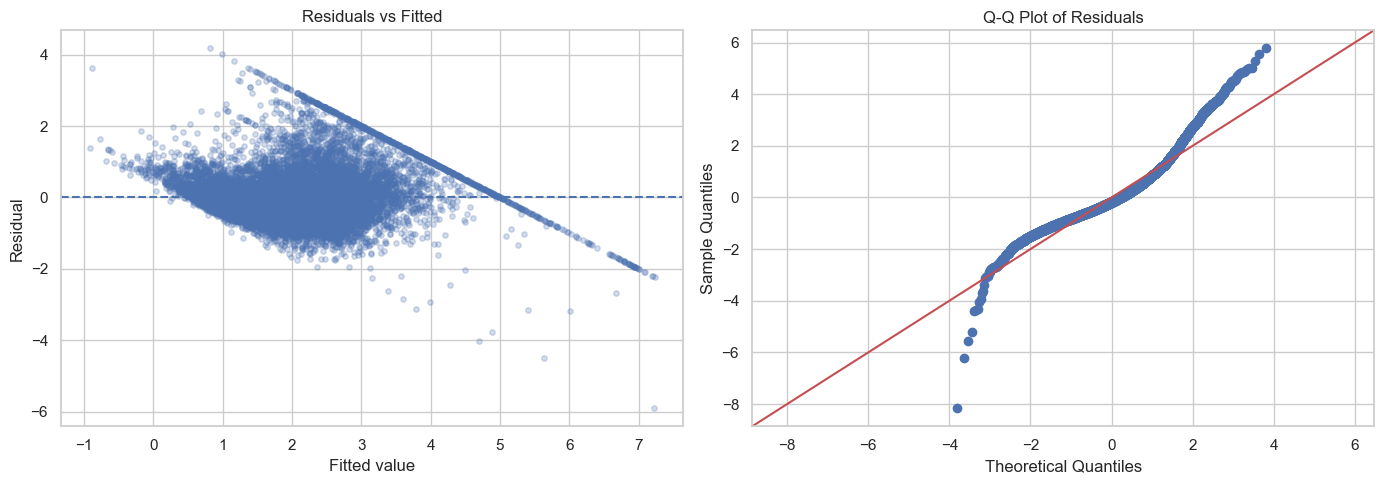

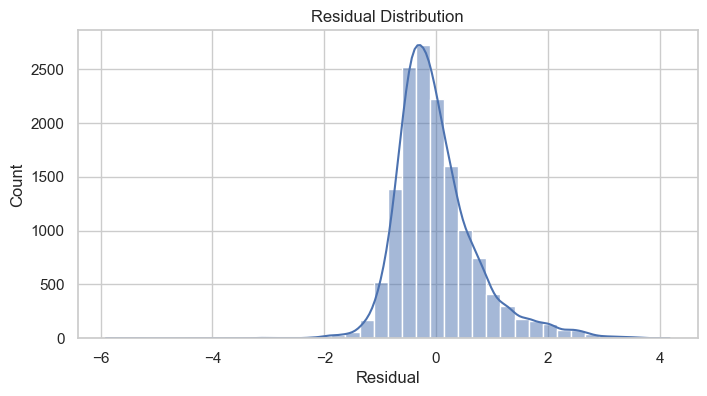

LM statistic     1.049215e+03
LM p-value      3.545439e-221
F statistic      1.413339e+02
F p-value       1.000092e-229
dtype: float64

In [13]:
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_breuschpagan

fitted_train = baseline_model.fittedvalues
residuals_train = baseline_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(fitted_train, residuals_train, alpha=0.25, s=15)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted value")
axes[0].set_ylabel("Residual")

qqplot(residuals_train, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(residuals_train, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

bp_test = het_breuschpagan(residuals_train, X_train_const)
bp_labels = ["LM statistic", "LM p-value", "F statistic", "F p-value"]
bp_results = dict(zip(bp_labels, bp_test))
pd.Series(bp_results)

### Diagnostic finding

The original analysis produced a Breusch–Pagan p-value effectively equal to **0.000**, providing strong evidence of **heteroscedasticity**. This means the baseline linear model should be treated primarily as a predictive benchmark; conventional OLS standard errors and inference should be interpreted with caution.

This also motivates testing robust regression, transformations, or nonlinear models in a later iteration.

## 9. Feature ablation

Ablation asks a practical question: **How much predictive performance is lost when one feature is removed?**

Each candidate feature is dropped, the OLS model is retrained on the same training set, and performance is measured on the validation set. A larger increase in RMSE means the removed feature was more useful to the baseline model.

In [14]:
y_val_pred_baseline = baseline_model.predict(X_val_const)
baseline_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_baseline))
baseline_mae = mean_absolute_error(y_val, y_val_pred_baseline)

ablation_results = []

for feat in X.columns:
    X_train_drop = sm.add_constant(X_train.drop(columns=[feat]))
    X_val_drop = sm.add_constant(X_val.drop(columns=[feat]))

    model_drop = sm.OLS(y_train, X_train_drop).fit()
    y_val_pred = model_drop.predict(X_val_drop)

    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae = mean_absolute_error(y_val, y_val_pred)

    ablation_results.append({
        "feature_dropped": feat,
        "rmse": rmse,
        "mae": mae,
        "delta_rmse": rmse - baseline_rmse,
        "delta_mae": mae - baseline_mae,
    })

ablation_df = (
    pd.DataFrame(ablation_results)
    .sort_values("delta_rmse", ascending=False)
    .reset_index(drop=True)
) #preserves a reference copy for reproducible experiments

print(f"Baseline validation RMSE: {baseline_rmse:.4f}")
print(f"Baseline validation MAE:  {baseline_mae:.4f}")
ablation_df.round(6)

Baseline validation RMSE: 0.7354
Baseline validation MAE:  0.5335


,feature_dropped,rmse,mae,delta_rmse,delta_mae
0,MedInc,0.883922,0.668591,0.148480,0.135139
1,Latitude,0.792805,0.579248,0.057363,0.045796
2,Longitude,0.789531,0.578531,0.054089,0.045079
3,AveBedrms,0.745311,0.545492,0.009869,0.012041
4,HouseAge,0.743913,0.538500,0.008470,0.005048
5,AveRooms,0.740748,0.540978,0.005306,0.007526
6,AveOccup,0.736263,0.534183,0.000821,0.000731
7,Population,0.735442,0.533452,-0.000000,0.000000


### Ablation finding

The strongest signal is **`MedInc`**. In the original results, removing it increased validation RMSE by about **0.148**, far more than removing any other feature. `Latitude` and `Longitude` were the next most consequential features.

This reinforces two themes from the exploratory analysis: **income is the dominant linear predictor**, while **geography contributes meaningful additional signal**.

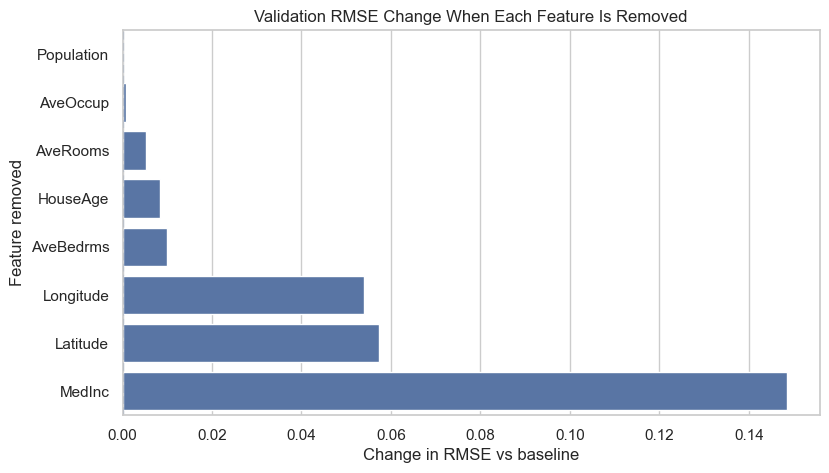

In [15]:
plt.figure(figsize=(9, 5))
plot_df = ablation_df.sort_values("delta_rmse")
sns.barplot(data=plot_df, x="delta_rmse", y="feature_dropped")
plt.axvline(0, linestyle="--")
plt.title("Validation RMSE Change When Each Feature Is Removed")
plt.xlabel("Change in RMSE vs baseline")
plt.ylabel("Feature removed")
plt.show()

## 10. Final model and test-set evaluation

After the validation-stage analysis, the final baseline is retrained using the combined **training + validation** data. The test set remains untouched until this point and provides the final out-of-sample benchmark.

In [16]:
X_train_plus_val = pd.concat([X_train, X_val], axis=0)
y_train_plus_val = pd.concat([y_train, y_val], axis=0)

final_model = sm.OLS(
    y_train_plus_val,
    sm.add_constant(X_train_plus_val)
).fit()

y_test_pred = final_model.predict(sm.add_constant(X_test))

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

metrics_df = pd.DataFrame([{
    "RMSE": rmse_test,
    "MAE": mae_test,
    "R2": r2_test,
}])

metrics_df.round(6)

,RMSE,MAE,R2
0,0.721768,0.521688,0.606031


### Final baseline result

The original completed analysis reported approximately:

| Metric | Test result |
|---|---:|
| **RMSE** | **0.7218** |
| **MAE** | **0.5217** |
| **R²** | **0.6060** |

Because `MedHouseVal` is measured in $100,000s, an RMSE of **0.7218** corresponds to roughly **$72,180** in the dataset's target units. These numbers are a benchmark for future models, not evidence that the model is suitable for real-world valuation decisions.

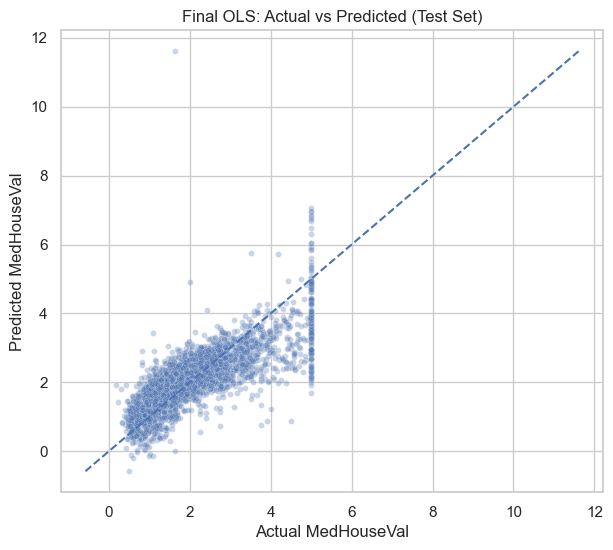

In [17]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.3, s=18)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())] # defines equal limits for the predicted-versus-actual plot
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Final OLS: Actual vs Predicted (Test Set)")
plt.show()

## 11. Conclusions

### What the analysis established

- The dataset is complete, but several predictors contain substantial outliers and skew.
- **`MedInc` is the strongest linear predictor** of median house value and the most important feature in the ablation study.
- **Geographic variables matter**: `Latitude` and `Longitude` improve predictive performance even though simple North/South and Coastal/Inland mean comparisons are not statistically significant at the 5% level.
- The OLS baseline explains roughly **61% of test-set variance** (`R² ≈ 0.606`).
- Residual diagnostics show clear **heteroscedasticity**, so the baseline's classical OLS inference should not be treated as fully reliable.

### What this baseline does not establish

This analysis is observational and cross-sectional. It does **not** establish causal relationships, future price movements, investment returns, or location-specific market recommendations. The geographic boundaries are analytical simplifications, and the dataset is not a live market dataset.

### Reproducibility

Run the notebook from top to bottom in a Python environment with `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `scikit-learn`, and `statsmodels` installed. The dataset is loaded through scikit-learn's California Housing dataset loader.